Initializing 250000 particles...
0. Warming up Numba JIT compiler (takes ~1s)...

1. Running Standalone Async FIRE for N=250000...
Step 0/400 | Energy: 7.1125e+02 | Elapsed: 8.1s
Step 10/400 | Energy: 2.7252e+02 | Elapsed: 99.6s
Step 20/400 | Energy: 1.3180e+02 | Elapsed: 195.4s
Step 30/400 | Energy: 6.9539e+01 | Elapsed: 289.5s
Step 40/400 | Energy: 1.7963e+01 | Elapsed: 384.9s
Step 50/400 | Energy: 9.3676e+00 | Elapsed: 477.8s
Step 60/400 | Energy: 4.6270e+00 | Elapsed: 573.6s
Step 70/400 | Energy: 2.1424e+00 | Elapsed: 668.6s
Step 80/400 | Energy: 1.0795e+00 | Elapsed: 762.1s
Step 90/400 | Energy: 8.1111e-01 | Elapsed: 857.3s
Step 100/400 | Energy: 5.4675e-01 | Elapsed: 948.3s
Step 110/400 | Energy: 3.3754e-01 | Elapsed: 1044.5s
Step 120/400 | Energy: 1.9616e-01 | Elapsed: 1140.4s
Step 130/400 | Energy: 1.1361e-01 | Elapsed: 1237.8s
Step 140/400 | Energy: 6.5896e-02 | Elapsed: 1332.6s
Step 150/400 | Energy: 3.8698e-02 | Elapsed: 1424.4s
Step 160/400 | Energy: 2.3478e-02 | Elapsed: 1

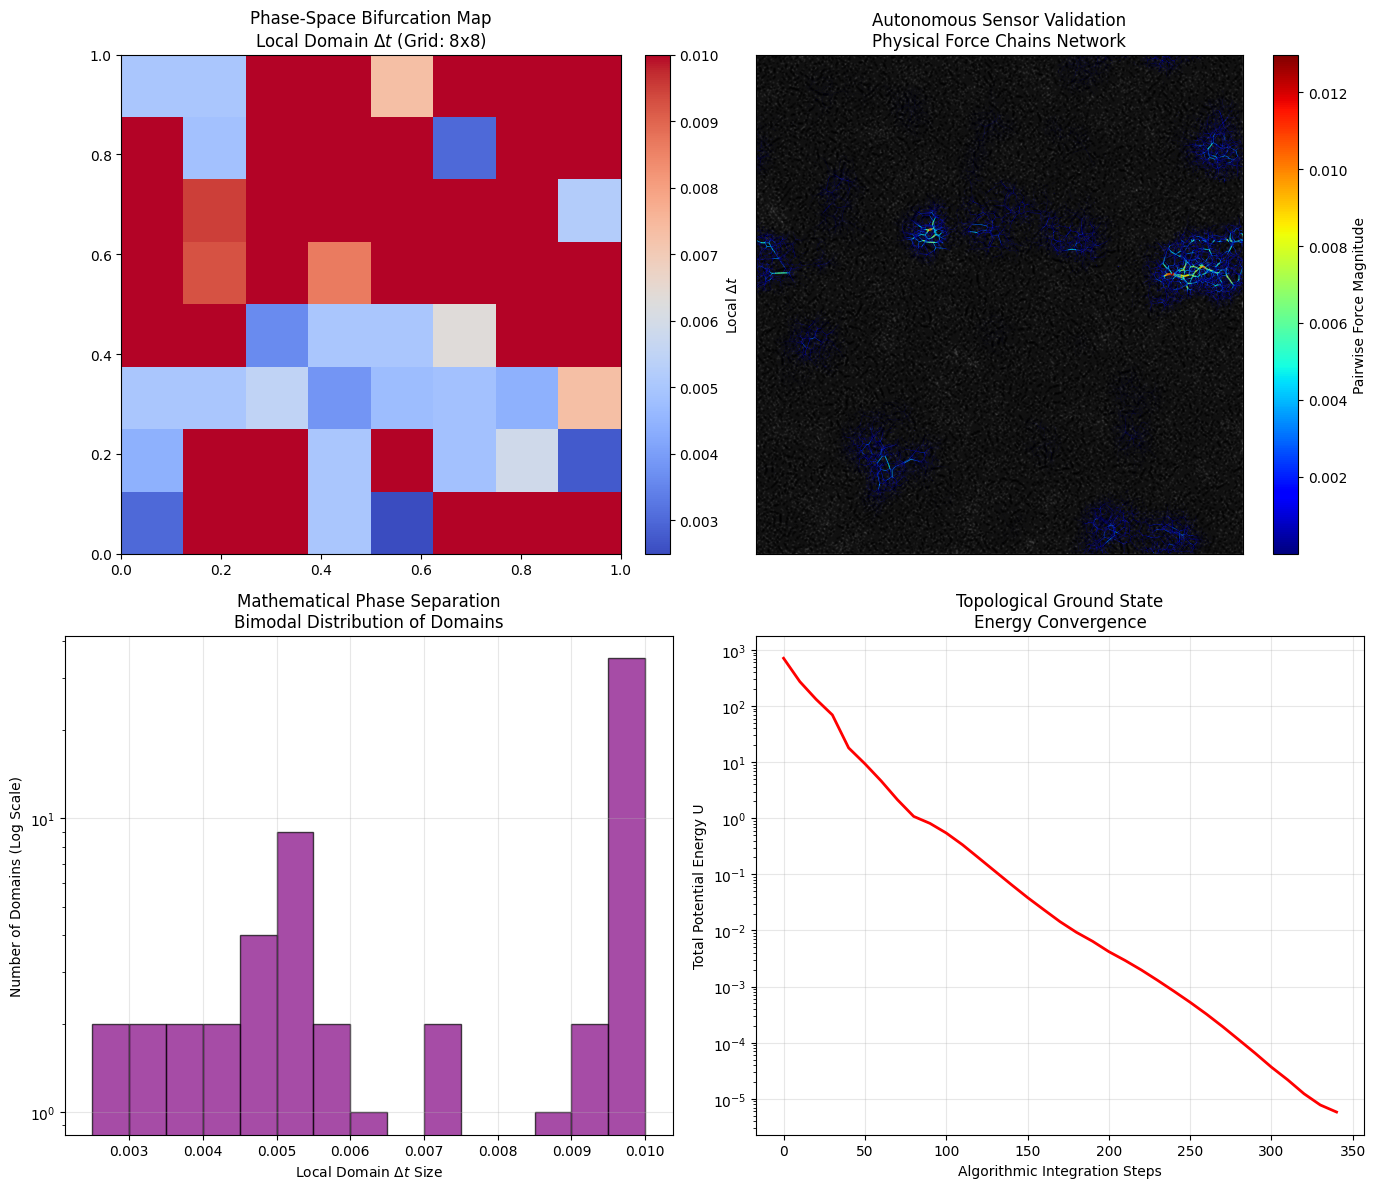

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import time
from numba import njit, prange

# ==========================================
# 1. SYSTEM & FIRE PARAMETERS
# ==========================================
N_ATOMS = 250000
BOX_SIZE = 1.0
TARGET_FRACTION = 0.82
# Dynamic radius based on N_ATOMS to strictly ensure jamming
RADIUS = np.sqrt((TARGET_FRACTION * BOX_SIZE**2) / (N_ATOMS * np.pi))
K_SPRING = 5000.0
MASS = 1.0
GRID_DIVS = 8  # Increased for a higher resolution heatmap

DT_INIT = 0.001
DT_MAX = 0.01
N_MIN = 5
F_INC = 1.1
F_DEC = 0.5
ALPHA_START = 0.1
F_ALPHA = 0.99
TOL = 1e-4

# ==========================================
# 2. NUMBA JIT-COMPILED CORE PHYSICS 
# ==========================================
@njit(parallel=True)
def get_forces_mpt_numba(pos, atom_dt, radius, k_spring):
    N = len(pos)
    forces = np.zeros_like(pos)
    forces_dt = np.zeros_like(pos)
    cutoff = 2.0 * radius
    for i in prange(N):
        for j in range(N):
            if i == j: continue
            
            # FIX 1: Use unique intermediate variables to break the SSA cycle
            dx_raw = pos[i, 0] - pos[j, 0]
            dy_raw = pos[i, 1] - pos[j, 1]
            
            dx = dx_raw - np.round(dx_raw)
            dy = dy_raw - np.round(dy_raw)
            
            dist = np.sqrt(dx**2 + dy**2)
            if dist < cutoff:
                f_mag = k_spring * (cutoff - dist)
                if dist > 1e-12:
                    fx = (dx / dist) * f_mag
                    fy = (dy / dist) * f_mag
                else:
                    fx = 0.0
                    fy = 0.0
                
                forces[i, 0] += fx
                forces[i, 1] += fy
                dt_ij = min(atom_dt[i], atom_dt[j])
                forces_dt[i, 0] += fx * dt_ij
                forces_dt[i, 1] += fy * dt_ij
    return forces, forces_dt

@njit(parallel=True)
def get_total_energy_numba(pos, radius, k_spring):
    N = len(pos)
    total_energy = 0.0
    cutoff = 2.0 * radius
    for i in prange(N):
        for j in range(i + 1, N):
            
            # FIX 1: Use unique intermediate variables
            dx_raw = pos[i, 0] - pos[j, 0]
            dy_raw = pos[i, 1] - pos[j, 1]
            
            dx = dx_raw - np.round(dx_raw)
            dy = dy_raw - np.round(dy_raw)
            
            dist = np.sqrt(dx**2 + dy**2)
            if dist < cutoff:
                overlap = cutoff - dist
                # FIX 2: Accumulate directly into the main reduction variable (no local_e)
                total_energy += 0.5 * k_spring * overlap**2
                
    return total_energy

@njit
def extract_force_chains(pos, radius, k_spring):
    N = len(pos)
    cutoff = 2.0 * radius
    # Pre-allocate array assuming max ~15 contacts per atom (safeguard)
    max_contacts = N * 15 
    lines = np.zeros((max_contacts, 2, 2), dtype=np.float64)
    force_mags = np.zeros(max_contacts, dtype=np.float64)
    
    idx = 0
    for i in range(N):
        for j in range(i+1, N):
            dx_raw = pos[i, 0] - pos[j, 0]
            dy_raw = pos[i, 1] - pos[j, 1]
            
            dx = dx_raw - np.round(dx_raw)
            dy = dy_raw - np.round(dy_raw)
            
            dist = np.sqrt(dx**2 + dy**2)
            if dist < cutoff:
                if idx < max_contacts:
                    lines[idx, 0, 0] = pos[i, 0]
                    lines[idx, 0, 1] = pos[i, 1]
                    lines[idx, 1, 0] = pos[i, 0] - dx
                    lines[idx, 1, 1] = pos[i, 1] - dy
                    force_mags[idx] = k_spring * (cutoff - dist)
                    idx += 1
                    
    return lines[:idx], force_mags[:idx]

def map_atoms_to_grid(pos, divs):
    ix = np.clip(np.floor(pos[:, 0] * divs).astype(int), 0, divs-1)
    iy = np.clip(np.floor(pos[:, 1] * divs).astype(int), 0, divs-1)
    return ix * divs + iy

# ==========================================
# 3. STANDALONE ASYNC FIRE ENGINE
# ==========================================
def run_standalone_async_fire(pos_init, max_steps=500):
    pos = np.copy(pos_init)
    vel = np.zeros_like(pos)
    n_domains = GRID_DIVS * GRID_DIVS
    
    d_dt = np.full(n_domains, DT_INIT)
    d_alpha = np.full(n_domains, ALPHA_START)
    d_npos = np.zeros(n_domains, dtype=int)
    
    energy_history = []
    
    atom_indices = map_atoms_to_grid(pos, GRID_DIVS)
    forces, forces_dt = get_forces_mpt_numba(pos, d_dt[atom_indices], RADIUS, K_SPRING)
    
    t0 = time.time()
    for step in range(max_steps):
        if step % 10 == 0:
            e_current = get_total_energy_numba(pos, RADIUS, K_SPRING)
            energy_history.append(e_current)
            print(f"Step {step}/{max_steps} | Energy: {e_current:.4e} | Elapsed: {time.time()-t0:.1f}s")
            
        vel += 0.5 * forces_dt / MASS
        pos += vel * d_dt[atom_indices][:, np.newaxis]
        pos = np.mod(pos, BOX_SIZE)
        
        atom_indices = map_atoms_to_grid(pos, GRID_DIVS)
        forces_new, forces_dt_new = get_forces_mpt_numba(pos, d_dt[atom_indices], RADIUS, K_SPRING)
        vel += 0.5 * forces_dt_new / MASS
        forces = forces_new; forces_dt = forces_dt_new
        
        p_domain = np.zeros(n_domains)
        np.add.at(p_domain, atom_indices, np.sum(forces * vel, axis=1))
        
        atom_alpha = d_alpha[atom_indices][:, np.newaxis]
        v_mag = np.linalg.norm(vel, axis=1, keepdims=True)
        f_mag = np.linalg.norm(forces, axis=1, keepdims=True)
        mask = (f_mag > 1e-12).flatten()
        if np.any(mask): 
            vel[mask] = (1 - atom_alpha[mask]) * vel[mask] + atom_alpha[mask] * (forces[mask]/f_mag[mask]) * v_mag[mask]
            
        mask_up = p_domain > 0
        d_npos[mask_up] += 1
        mask_grow = mask_up & (d_npos > N_MIN)
        d_dt[mask_grow] = np.minimum(d_dt[mask_grow] * F_INC, DT_MAX)
        d_alpha[mask_grow] *= F_ALPHA
        
        mask_down = p_domain <= 0
        d_npos[mask_down] = 0; d_dt[mask_down] *= F_DEC; d_alpha[mask_down] = ALPHA_START
        vel[np.isin(atom_indices, np.where(mask_down)[0])] = 0.0
        
        if np.sqrt(np.sum(forces**2) / (2 * N_ATOMS)) < TOL: 
            print(f"Converged at step {step}!")
            break
            
    return pos, forces, d_dt, np.array(energy_history), time.time() - t0

# ==========================================
# 4. HPC EXECUTION AND DATA EXPORT
# ==========================================
if __name__ == '__main__':
    import os
    np.random.seed(42)
    print(f"Initializing {N_ATOMS} particles for HPC run...")
    initial_pos = np.random.rand(N_ATOMS, 2)
    
    print("0. Warming up Numba JIT compiler...")
    _ = get_forces_mpt_numba(initial_pos[:10], np.ones(10), RADIUS, K_SPRING)
    _ = get_total_energy_numba(initial_pos[:10], RADIUS, K_SPRING)
    
    print(f"\n1. Running Standalone Async FIRE for N={N_ATOMS}...")
    # NOTE: For 250k atoms, you might want to increase max_steps to 1000+
    pos_final, forces_final, dt_final, energy_hist, total_time = run_standalone_async_fire(initial_pos, max_steps=500)
    print(f"\nAsync FIRE Complete! Total Wall-Clock Time: {total_time:.2f} seconds.")
    
    print("\n2. Serializing Data to Disk...")
    # Save everything into a single compressed binary file
    filename = f"async_fire_N{N_ATOMS}_Grid{GRID_DIVS}.npz"
    np.savez_compressed(filename, 
                        pos_final=pos_final, 
                        dt_final=dt_final, 
                        energy_hist=energy_hist,
                        total_time=total_time,
                        radius=RADIUS,
                        k_spring=K_SPRING,
                        grid_divs=GRID_DIVS)
    
    print(f"Success! Data saved to {os.path.abspath(filename)}")
    print("Job finished safely. Exiting.")

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from mpl_toolkits.axes_grid1 import make_axes_locatable

print("\nGenerating Overlay Plot...")

fig, ax = plt.subplots(figsize=(10, 8))

# ==========================================
# 1. THE BACKGROUND: Mathematical State (Heatmap)
# ==========================================
# We use 'Blues_r' (reversed Blues). 
# Dark Blue = Tiny time step (bottleneck)
# White/Light Blue = Large time step (rattler void)
dt_grid = dt_final.reshape(GRID_DIVS, GRID_DIVS).T
heatmap = ax.imshow(dt_grid, cmap='Blues_r', origin='lower', extent=[0, 1, 0, 1], alpha=0.6)

# ==========================================
# 2. THE MIDDLE GROUND: The Particles
# ==========================================
# Plotted as tiny, semi-transparent dots just to provide spatial context
ax.scatter(pos_final[:, 0], pos_final[:, 1], s=1, c='black', alpha=0.15)

# ==========================================
# 3. THE FOREGROUND: Physical State (Force Chains)
# ==========================================
cutoff = 2.0 * RADIUS
lines = []
force_mags = []

for i in range(len(pos_final)):
    for j in range(i+1, len(pos_final)):
        dx = pos_final[i,0] - pos_final[j,0]
        dy = pos_final[i,1] - pos_final[j,1]
        dx -= np.round(dx); dy -= np.round(dy)
        dist = np.sqrt(dx**2 + dy**2)
        
        if dist < cutoff:
            lines.append([(pos_final[i,0], pos_final[i,1]), (pos_final[i,0]-dx, pos_final[i,1]-dy)])
            force_mags.append(K_SPRING * (cutoff - dist))

force_array = np.array(force_mags)
if len(lines) > 0:
    # Scale line thickness based on force (exaggerated for visual impact)
    lw = (force_array / np.max(force_array)) * 3.0 + 0.5
    # Use the 'autumn' colormap (Red to Yellow) to contrast against the blue background
    lc = LineCollection(lines, cmap='autumn', linewidths=lw)
    lc.set_array(force_array)
    ax.add_collection(lc)

# ==========================================
# 4. JOURNAL AESTHETICS & DUAL COLORBARS
# ==========================================
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("Autonomous Algorithmic Sensing of Physical Stress Networks\n(Background: Local $\Delta t$ | Foreground: Force Chains)", fontsize=14, pad=15)

# Create two beautiful, parallel colorbars
divider = make_axes_locatable(ax)

# Colorbar 1: The Math
cax1 = divider.append_axes("right", size="3%", pad=0.1)
cbar1 = plt.colorbar(heatmap, cax=cax1)
cbar1.set_label('Algorithmic State: Local $\Delta t$ (Math)', rotation=270, labelpad=15)

# Colorbar 2: The Physics
cax2 = divider.append_axes("right", size="3%", pad=0.4)
if len(lines) > 0:
    cbar2 = plt.colorbar(lc, cax=cax2)
    cbar2.set_label('Physical State: Pairwise Force (Physics)', rotation=270, labelpad=15)

plt.tight_layout()
plt.savefig('prl_hero_overlay.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()